# Thematic ETF Curse — the quant teardown 🪤

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Buy the dip?: Busted](https://img.shields.io/badge/Buy_the_--50%25_dip%3F-Busted-8b949e?style=flat-square)

**Claim (Ben-David, Franzoni, Kim & Moussawi, RFS 2023).** Specialized/thematic ETFs launch at peak hype and deliver ≈ −5%/yr risk-adjusted returns over their first years; the launch date is the sell signal.

**Design.** 48 thematic ETF launches 2005–2021 (launch = first candle, issuer-inception guard against ticker reuse), 13 broad plain-vanilla index-ETF launches as placebo, SPY market, ^IRX risk-free. Primary test: **calendar-time portfolio** of funds in event months 1..W, CAPM on SPY excess, **Newey-West t (lags 6)**. Calendar-time (Fama 1998) because pooled fund-month regressions pseudo-replicate the same crash months. One execution lag everywhere; total-return prices; excess-vs-excess. **Survivorship named: dead thematics are absent from yfinance, which biases AGAINST the finding.** As-of 2026-06-30, fingerprint `d3175d6dbc14`.

Frozen canonical numbers live in `R` (mirror of [docs/results.md](../docs/results.md)); real-tape cells recompute them from the cache.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from thematic_etf_curse import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX, RF = data.load_prices(), data.load_rf()
    UNIV = data.build_universe(PX, RF, as_of="2026-06-30")
    TH, BR = UNIV["thematic"], UNIV["broad"]
else:
    PX = RF = UNIV = None
    TH = BR = []
print("real cache present:", HAVE_REAL, "| thematic:", len(TH), "| broad placebo:", len(BR))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'fingerprint': 'd3175d6dbc14', 'n_thematic': 48, 'n_broad': 13, 'launches': '2005-2021', 'hype_vintage': 20, 'young36': (-16.3, -3.27, 1.64, 192, 8.7), 'young36_span': ('2008-07-31', '2024-06-30'), 'young12': (-15.0, -2.04, 1.64, 109, 4.5), 'seasoned': (-10.33, -1.82, 1.36, 182, 23.6), 'spread': (-0.26, -0.05, 158), 'placebo': (0.31, 1.17, 0.99, 72), 'curve': {12: -4.9, 24: -12.4, 36: -22.5, 48: -35.6}, 'curve_n': 48, 'perfund_median': -2.18, 'perfund_pct_neg': 65, 'perfund_n': 48, 'rob_lags12': (-16.3, -2.93), 'rob_min1': (-11.29, -2.32, 232), 'rob_exark': (-16.49, -3.34, 42), 'rob_pre18': (-18.94, -3.99, 28, 135), 'rob_post18': (-9.56, -0.97, 20, 74), 'short_gross': (16.3, 3.58), 'short': [(300, 13.21, 2.9), (600, 10.21, 2.24), (1000, 6.21, 1.37)], 'dip_events': 34, 'dip_alpha': -19.39, 'dip_t': -2.8, 'dip_beta': 1.63, 'dip_n': 83, 'dip_fwd12': (-15.1, 76, 34), 'dip_fwd36': (-36.6, 75, 32), 'syn': [(0.0, -0.76, -0.37), (-8.0, -8.76, -4.26)], 'syn_n': 181}


real cache present: True | thematic: 48 | broad placebo: 13


## 1 · Headline — calendar-time CAPM alphas

$(r_{p,t} - r_{f,t}) = \alpha + \beta\,(r_{m,t} - r_{f,t}) + \varepsilon_t$, HAC t on $\alpha$ (Bartlett, 6 lags). Portfolios: young thematics (event months 1–12, 1–36; ≥3 members), seasoned thematics (37+), the beta-controlled young−seasoned spread, and the broad-launch placebo.

In [2]:
if HAVE_REAL:
    rows = []
    for lbl, res in (('young 1-12', st.young_alpha(UNIV, TH, w=12)),
                     ('young 1-36', st.young_alpha(UNIV, TH, w=36)),
                     ('seasoned 37+', st.seasoned_alpha(UNIV, TH)),
                     ('BROAD placebo 1-36', st.young_alpha(UNIV, BR, w=36))):
        rows.append({'book': lbl, 'alpha %/yr': round(res['alpha_ann_pct'], 2),
                     'HAC t': round(res['t_alpha'], 2), 'beta': round(res['beta'], 2),
                     'months': res['n']})
    sp = st.young_vs_seasoned_spread(UNIV, TH, w=36)
    rows.insert(3, {'book': 'young - seasoned spread', 'alpha %/yr': round(sp['alpha_ann_pct'], 2),
                    'HAC t': round(sp['t_alpha'], 2), 'beta': round(sp['beta'], 2), 'months': sp['n']})
    display(pd.DataFrame(rows).set_index('book'))
else:
    print('cache missing — canonical: young36', R['young36'], '| placebo', R['placebo'])

,alpha %/yr,HAC t,beta,months
book,,,,
young 1-12,-15.00,-2.04,1.64,109
young 1-36,-16.30,-3.27,1.64,192
seasoned 37+,-10.33,-1.82,1.36,182
young - seasoned spread,-0.26,-0.05,0.20,158
BROAD placebo 1-36,0.31,1.17,0.99,72


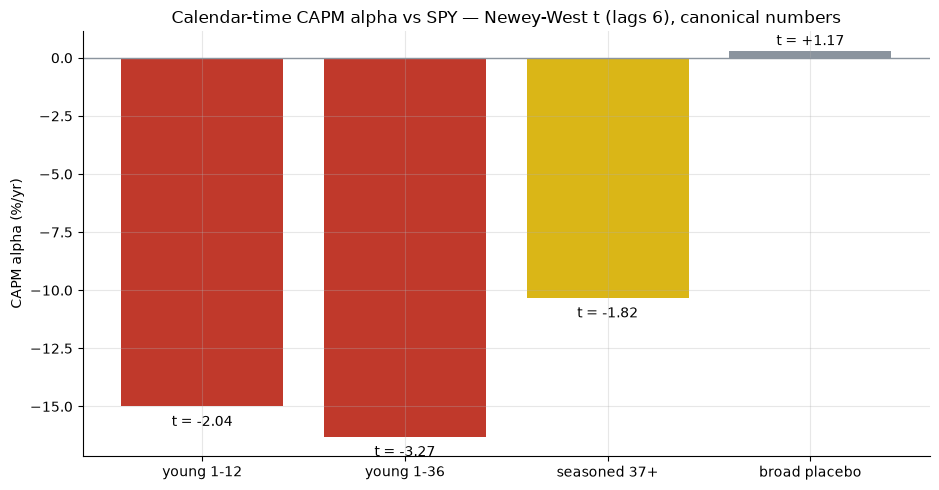

In [3]:
fig, ax = plt.subplots()
labels = ['young 1-12', 'young 1-36', 'seasoned 37+', 'broad placebo']
alphas = [R['young12'][0], R['young36'][0], R['seasoned'][0], R['placebo'][0]]
ts     = [R['young12'][1], R['young36'][1], R['seasoned'][1], R['placebo'][1]]
cols = [RED, RED, AMBER, GREY]
bars = ax.bar(labels, alphas, color=cols)
for b, t in zip(bars, ts):
    ax.annotate(f't = {t:+.2f}', (b.get_x() + b.get_width()/2, b.get_height()),
                textcoords='offset points', xytext=(0, -14 if b.get_height() < 0 else 4),
                ha='center', fontsize=10)
ax.axhline(0, color=GREY, lw=1)
ax.set_ylabel('CAPM alpha (%/yr)')
ax.set_title('Calendar-time CAPM alpha vs SPY — Newey-West t (lags 6), canonical numbers')
plt.tight_layout(); plt.show()

**Signal — REAL.** Young thematics (1–36): **−16.30%/yr, HAC t = −3.27**; the 1–12 book −15.00%/yr (t = −2.04). The placebo is clean (+0.31%/yr, t = +1.17, beta 0.99): the construction does not manufacture bleed out of *launching* — only out of launching **hype**.

**The honest nuance, on the stamp:** seasoned thematics bleed too (−10.33%/yr, t = −1.82), and the beta-controlled young−seasoned spread is **−0.26%/yr, t = −0.05**. The tape certifies *thematics bleed from the first candle onward*; it cannot certify that youth is **extra** toxic relative to being a thematic at all. Ben-David et al.'s launch-timing framing survives in the practical sense (the launch date starts the clock and marked the attention peak), not as a young-vs-old spread.

> 💡 **In plain words.** New theme funds lost hugely versus their risk; new boring funds didn't. But old theme funds kept losing as well — the birthday is when the bleeding *starts*, not the only bad part.

## 2 · Event-time curve + coverage

Mean CAPM-abnormal return by event month (per-fund **full-sample** beta — a documented look-ahead, descriptive only), cumulated; plus the young-book membership over calendar time (the launch waves: 2008 clean energy, 2014-16 robotics/cyber, 2018-21 everything).

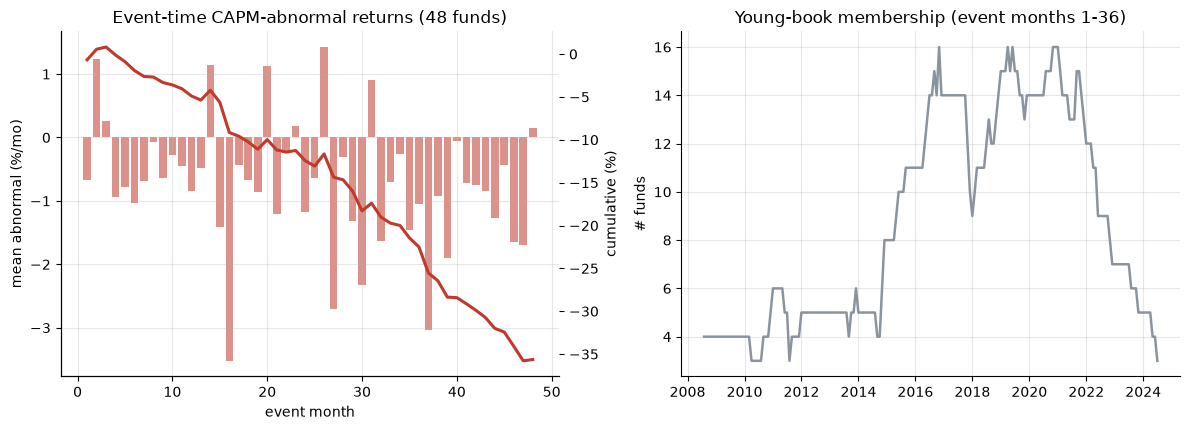

cumulative by k: {12: np.float64(-4.9), 24: np.float64(-12.4), 36: np.float64(-22.5), 48: np.float64(-35.6)}


In [4]:
if HAVE_REAL:
    ec = st.event_curve(UNIV, TH, k_max=48)
    _, cnt = st.calendar_time_portfolio(UNIV, TH, 1, 36)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
    axes[0].bar(ec.index, ec['mean_ab'] * 100, color=RED, alpha=.55, label='mean abnormal (%/mo)')
    ax2 = axes[0].twinx(); ax2.plot(ec.index, ec['cum_ab_pct'], color=RED, lw=2.2, label='cumulative (%)')
    ax2.grid(False)
    axes[0].set_xlabel('event month'); axes[0].set_ylabel('mean abnormal (%/mo)')
    ax2.set_ylabel('cumulative (%)'); axes[0].set_title('Event-time CAPM-abnormal returns (48 funds)')
    axes[1].plot(cnt.index, cnt.values, color=GREY, lw=1.8)
    axes[1].set_title('Young-book membership (event months 1-36)'); axes[1].set_ylabel('# funds')
    plt.tight_layout(); plt.show()
    print('cumulative by k:', {k: round(ec.loc[k, 'cum_ab_pct'], 1) for k in (12, 24, 36, 48)})
else:
    print('canonical curve:', R['curve'])

Canonical: **−4.9% (12m), −12.4% (24m), −22.5% (36m), −35.6% (48m)**, all 48 funds contributing at every horizon. The bleed is steady, not a single crash.

### Per-fund vs calendar-time — the clustering is the mechanism
One first-36-months alpha per fund: median **−2.18%/yr**, **65% negative** (n=48) — much milder than the calendar-time −16.30%/yr. The gap is the paper's mechanism in one contrast: launches **cluster at attention peaks**, so the calendar months crowded with young funds (2008, 2021-22) were precisely the bleed months. Equal-weighting *months* (what a launch-buying dollar experiences) is the economically relevant footing; equal-weighting *funds* dilutes the crowded disasters.

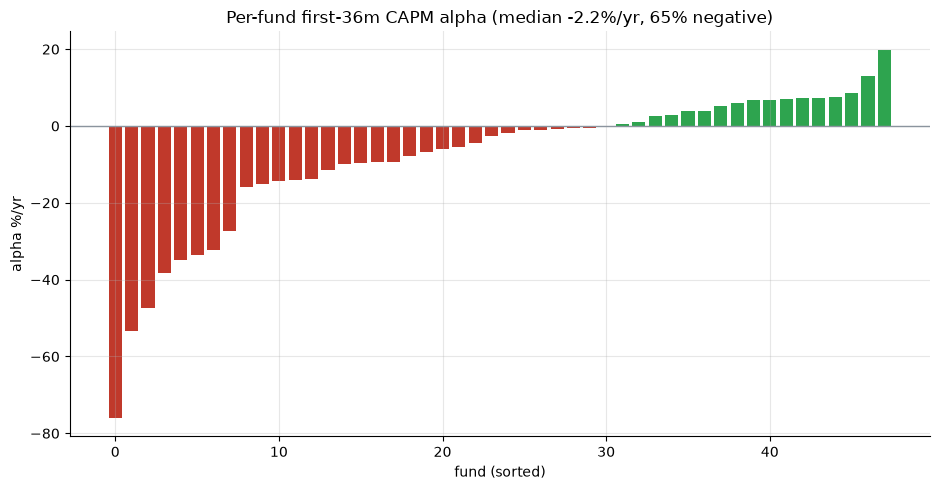

canonical per-fund: median -2.18 %/yr, 65 % negative


In [5]:
if HAVE_REAL:
    pf = st.per_fund_alphas(UNIV, TH, w=36)
    fig, ax = plt.subplots()
    v = pf['alpha_ann_pct'].sort_values()
    ax.bar(range(len(v)), v, color=[RED if x < 0 else GREEN for x in v])
    ax.axhline(0, color=GREY, lw=1)
    ax.set_title(f'Per-fund first-36m CAPM alpha (median {v.median():+.1f}%/yr, '
                 f'{(v < 0).mean()*100:.0f}% negative)')
    ax.set_ylabel('alpha %/yr'); ax.set_xlabel('fund (sorted)')
    plt.tight_layout(); plt.show()
print('canonical per-fund: median', R['perfund_median'], '%/yr,', R['perfund_pct_neg'], '% negative')

## 3 · Robustness

Lag choice, membership floor, the ARK complex, and the vintage split.

In [6]:
if HAVE_REAL:
    rows = [('headline (lags 6, >=3 members)', st.young_alpha(UNIV, TH, w=36)),
            ('NW lags = 12', st.young_alpha(UNIV, TH, w=36, lags=12)),
            ('min members = 1', st.young_alpha(UNIV, TH, w=36, min_members=1)),
            ('ex-ARK', st.young_alpha(UNIV, [t for t in TH if not t.startswith('ARK') and t != 'IZRL'], w=36)),
            ('pre-2018 vintage', st.young_alpha(UNIV, [t for t in TH if UNIV['launch'][t].year < 2018], w=36)),
            ('2018+ vintage', st.young_alpha(UNIV, [t for t in TH if UNIV['launch'][t].year >= 2018], w=36))]
    display(pd.DataFrame([{'variant': l, 'alpha %/yr': round(r['alpha_ann_pct'], 2),
                           'HAC t': round(r['t_alpha'], 2), 'months': r['n']} for l, r in rows])
            .set_index('variant'))
else:
    print('canonical:', R['rob_lags12'], R['rob_min1'], R['rob_exark'], R['rob_pre18'], R['rob_post18'])

,alpha %/yr,HAC t,months
variant,,,
"headline (lags 6, >=3 members)",-16.30,-3.27,192
NW lags = 12,-16.30,-2.93,192
min members = 1,-11.29,-2.32,232
ex-ARK,-16.49,-3.34,192
pre-2018 vintage,-18.94,-3.99,135
2018+ vintage,-9.56,-0.97,74


The headline survives everything structural: lags 12 → **t = −2.93**; membership floor dropped → −11.29%/yr, **t = −2.32**; the entire ARK complex removed → −16.49%/yr, **t = −3.34**. The vintage split: pre-2018 launches −18.94%/yr (**t = −3.99**); the 2018+ vintage alone is −9.56%/yr at **t = −0.97** — 74 calendar months that are all one overlapping macro episode (2018→2024), so the sub-sample carries little independent information. Same sign, not separately certifiable — said out loud, not hidden.

> 💡 **In plain words.** However we slice it, the answer keeps its sign; the only slice that can't clear the bar alone is the shortest one, because six overlapping years is barely one weather system.

## 4 · Tradability — shorting the curse

Short the young book, hedge β × SPY long. Costs: 5 bps one-way × NAV amortized over the 36-month window (entries + exits, both legs); **borrow paid on the full short notional**, swept 300/600/1000 bps/yr — young niche ETFs are exactly where borrow gets ugly (MSOS-type names ran to double digits in the wild).

gross: +16.30%/yr  t=+3.58  (beta hedge 1.64)


,net %/yr,HAC t
borrow bps/yr,,
300,13.21,2.90
600,10.21,2.24
1000,6.21,1.37


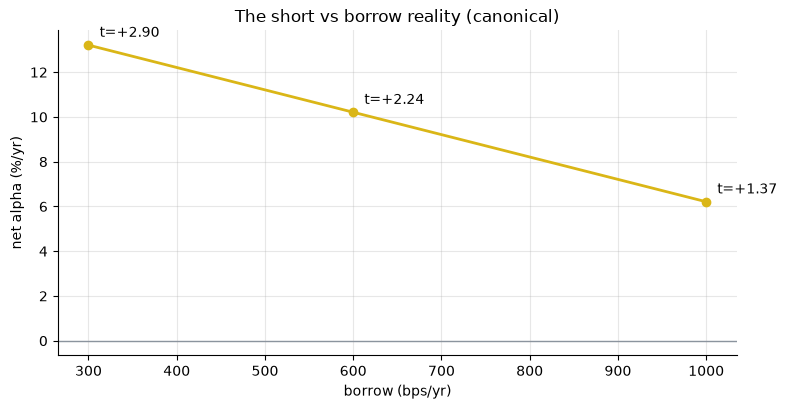

In [7]:
if HAVE_REAL:
    rows = []
    for b in (300.0, 600.0, 1000.0):
        so = st.short_overlay(UNIV, TH, w=36, cost_bps=5.0, borrow_bps_ann=b)
        rows.append({'borrow bps/yr': int(b), 'net %/yr': round(so['net_ann_pct'], 2),
                     'HAC t': round(so['t_net'], 2)})
    print(f"gross: {so['gross_ann_pct']:+.2f}%/yr  t={so['t_gross']:+.2f}  (beta hedge {so['beta_hedge']:.2f})")
    display(pd.DataFrame(rows).set_index('borrow bps/yr'))
fig, ax = plt.subplots(figsize=(8, 4.2))
bb = [r[0] for r in R['short']]; nn = [r[1] for r in R['short']]; tt = [r[2] for r in R['short']]
ax.plot(bb, nn, 'o-', color=AMBER, lw=2)
for x, y, t in zip(bb, nn, tt):
    ax.annotate(f't={t:+.2f}', (x, y), textcoords='offset points', xytext=(8, 6))
ax.axhline(0, color=GREY, lw=1)
ax.set_xlabel('borrow (bps/yr)'); ax.set_ylabel('net alpha (%/yr)')
ax.set_title('The short vs borrow reality (canonical)')
plt.tight_layout(); plt.show()

**Tradability — FRAGILE.** Net **+13.21%/yr (t = +2.90)** at 300 bps borrow, still clearing at 600 (**t = +2.24**), dead by 1000 (**t = +1.37**). And the modeled sweep is generous: availability on young niche ETFs is thin, recalls and squeezes on a β≈1.6 short book are real, and the bleed is concentrated in the very names with the worst borrow. The *accessible* implementation — refuse the launch, buy the broad fund — captures the effect at zero cost but produces no short alpha. A real signal in a hard-to-hold wrapper.

## 5 · Third axis — buy the −50% dip?

First month-end ≥50% below the post-launch running max (total-return levels), enter the **next** month (one lag), hold 36 months. Calendar-time book + per-event forward runs vs SPY.

In [8]:
if HAVE_REAL:
    dp = st.dip_portfolio(UNIV, TH, dd=0.50, hold=36)
    f12, f36 = np.array(dp['fwd12']), np.array(dp['fwd36'])
    print(f"events: {dp['n_events']} | book alpha {dp['alpha_ann_pct']:+.2f}%/yr  t={dp['t_alpha']:+.2f}  "
          f"beta {dp['beta']:.2f}  ({dp['n']} months)")
    print(f"fwd 12m vs SPY: {f12.mean()*100:+.1f} pp  ({(f12<0).mean()*100:.0f}% negative, n={len(f12)})")
    print(f"fwd 36m vs SPY: {f36.mean()*100:+.1f} pp  ({(f36<0).mean()*100:.0f}% negative, n={len(f36)})")
else:
    print('canonical: alpha', R['dip_alpha'], 't', R['dip_t'], '| fwd36', R['dip_fwd36'])

events: 34 | book alpha -19.39%/yr  t=-2.80  beta 1.63  (83 months)
fwd 12m vs SPY: -15.1 pp  (76% negative, n=34)
fwd 36m vs SPY: -36.6 pp  (75% negative, n=32)


**BUSTED.** The dip-bought book bleeds **−19.39%/yr** of alpha (**t = −2.80**) — *faster* than the young book itself. Forward vs SPY: **−15.1 pp** over 12m (76% negative), **−36.6 pp** over 36m (75% negative, n=32). −50% in a thematic is mid-bleed, not value.

> 💡 **In plain words.** Half-off on a hype fund isn't a sale price — it's the hype being half-way done deflating.

## 6 · Synthetic positive control — the machinery is faithful

Deterministic seeded panel (staggered launches, β ≈ 1.2, idio noise) with a **planted** post-launch alpha drag over event months 1–36. The null (drag 0) must not fire; the planted drag must be recovered. *(Machinery proof only — never cited in support of the stamps.)*

In [9]:
for drag in (0.0, -0.08):
    u = data.synthetic_world(drag_ann=drag, seed=622)
    r = st.young_alpha(u, u['thematic'], w=36)
    print(f"planted drag {drag*100:+5.0f}%/yr -> recovered alpha {r['alpha_ann_pct']:+.2f}%/yr  "
          f"HAC t = {r['t_alpha']:+.2f}  ({r['n']} months)")

planted drag    +0%/yr -> recovered alpha -0.76%/yr  HAC t = -0.37  (181 months)


planted drag    -8%/yr -> recovered alpha -8.76%/yr  HAC t = -4.26  (181 months)


Null: −0.76%/yr, t = −0.37 (no manufactured bleed). Planted −8%/yr: recovered −8.76%/yr, t = −4.26.

## Verdict

- **Signal — REAL.** Young-thematics calendar-time CAPM alpha **−16.30%/yr, HAC t = −3.27** (W=12: t = −2.04), robust to lags/floor/ex-ARK; broad-launch placebo clean; **survivorship (named) biases against the finding**. Nuance on the stamp: the young-vs-seasoned spread is ≈ 0 — the category bleeds at every age, launch is when it starts.
- **Tradability — FRAGILE.** The hedged short clears at modeled borrow (300–600 bps, t = 2.90/2.24) but dies at real-world niche borrow (1000 bps → t = 1.37); capacity and recalls throttle it; the free version is avoidance, not alpha.
- **Buy the −50% dip? — BUSTED.** Dip book −19.39%/yr (t = −2.80); the average dip lost 36.6 pp to SPY over 3 years; 75% of events negative.

*Reproduce: `python examples/verify.py` (as-of 2026-06-30, fingerprint `d3175d6dbc14`). Sources: [docs/references.md](../docs/references.md).*